# Raw data overview

A first look at `data/01-raw_data/raw_data.csv` (Toronto Beaches Water Quality) before writing the simulation.
Not part of the reproducible pipeline; the numbered files in `scripts/` are.

Run from the project root, or let the first cell move there.

In [1]:
import os
from pathlib import Path

import contextily as cx
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Move to the project root so relative paths match the scripts
if Path.cwd().name == "explore":
    os.chdir("../..")

pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

polars.config.Config

## Load

`eColi` is blank in the most recent rows, so its type is set directly rather than guessed.

In [2]:
raw = pl.read_csv(
    "data/01-raw_data/raw_data.csv",
    schema_overrides={"eColi": pl.Float64},
).with_columns(pl.col("collectionDate").str.to_date())

raw.schema

Schema([('_id', Int64),
        ('beachId', Int64),
        ('beachName', String),
        ('siteName', String),
        ('collectionDate', Date),
        ('eColi', Float64),
        ('geometry', String)])

The first ten rows, to see what each column looks like.

In [3]:
raw.head(10)

_id,beachId,beachName,siteName,collectionDate,eColi,geometry
i64,i64,str,str,date,f64,str
1,1,"""Marie Curtis Park East Beach""","""29W""",2026-09-16,null,"""{""coordinates"": [[-79.539696, 43.58592]], ""type"": ""MultiPoint""}"""
2,1,"""Marie Curtis Park East Beach""","""33W""",2026-09-16,null,"""{""coordinates"": [[-79.540886, 43.58486]], ""type"": ""MultiPoint""}"""
3,1,"""Marie Curtis Park East Beach""","""32W""",2026-09-16,null,"""{""coordinates"": [[-79.54056, 43.58511]], ""type"": ""MultiPoint""}"""
4,1,"""Marie Curtis Park East Beach""","""31W""",2026-09-16,null,"""{""coordinates"": [[-79.54039, 43.585304]], ""type"": ""MultiPoint""}"""
5,1,"""Marie Curtis Park East Beach""","""30W""",2026-09-16,null,"""{""coordinates"": [[-79.540054, 43.58561]], ""type"": ""MultiPoint""}"""
6,2,"""Sunnyside Beach""","""22W""",2026-09-16,null,"""{""coordinates"": [[-79.46005, 43.636723]], ""type"": ""MultiPoint""}"""
7,2,"""Sunnyside Beach""","""60W""",2026-09-16,null,"""{""coordinates"": [[-79.27211, 43.68313]], ""type"": ""MultiPoint""}"""
8,2,"""Sunnyside Beach""","""19W""",2026-09-16,null,"""{""coordinates"": [[-79.45411, 43.63711]], ""type"": ""MultiPoint""}"""
9,2,"""Sunnyside Beach""","""20W""",2026-09-16,null,"""{""coordinates"": [[-79.45564, 43.637165]], ""type"": ""MultiPoint""}"""


## Overview: size, missing values, distinct values

In [4]:
print(f"{raw.height:,} rows, {raw.width} columns")

pl.concat(
    [
        raw.null_count().with_columns(pl.lit("missing").alias("stat")),
        raw.select(pl.all().n_unique()).with_columns(pl.lit("distinct").alias("stat")),
    ],
    how="vertical_relaxed",
).select("stat", pl.exclude("stat"))

102,534 rows, 7 columns


stat,_id,beachId,beachName,siteName,collectionDate,eColi,geometry
str,u32,u32,u32,u32,u32,u32,u32
"""missing""",0,0,0,0,0,3543,0
"""distinct""",102534,10,10,52,2063,330,52


In [5]:
raw.null_count().with_columns(pl.lit("missing").alias("stat"))

_id,beachId,beachName,siteName,collectionDate,eColi,geometry,stat
u32,u32,u32,u32,u32,u32,u32,str
0,0,0,0,0,3543,0,"""missing"""


In [6]:
raw.null_count()

_id,beachId,beachName,siteName,collectionDate,eColi,geometry
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,3543,0


## Beaches and sites

Each beach has several sampling sites. How many sites per beach, and how many samples per site?

In [7]:
raw.group_by("beachId", "beachName").agg(
    n_sites=pl.col("siteName").n_unique(),
    sites=pl.col("siteName").unique().sort(),
    n_samples=pl.len(),
).sort("beachId")

beachId,beachName,n_sites,sites,n_samples
i64,str,u32,list[str],u32
1,"""Marie Curtis Park East Beach""",5,"[""29W"", ""30W"", … ""33W""]",10185
2,"""Sunnyside Beach""",5,"[""19W"", ""20W"", … ""60W""]",8354
3,"""Hanlan's Point Beach""",5,"[""2E"", ""3E"", … ""6E""]",10170
4,"""Gibraltar Point Beach""",6,"[""GP1"", ""GP2"", … ""GP6""]",10269
5,"""Centre Island Beach""",5,"[""10E"", ""11E"", … ""9E""]",10135
6,"""Ward's Island Beach""",5,"[""12E"", ""13E"", … ""16E""]",10160
7,"""Cherry Beach""",5,"[""17E"", ""18E"", … ""21E""]",10295
8,"""Woodbine Beaches""",5,"[""22E"", ""24E"", … ""29E""]",10300
9,"""Kew Balmy Beach""",6,"[""34E"", ""35E"", … ""40E""]",12366


## Samples per beach per year

Rows are beaches, columns are years, values are number of samples. Look for beaches that start late, stop early, or have gaps.

In [8]:
(
    raw.with_columns(year=pl.col("collectionDate").dt.year())
    .group_by("beachName", "year")
    .len()
    .sort("year")
    .pivot(on="year", index="beachName", values="len")
    .fill_null(0)
    .sort("beachName")
)

beachName,2007,2008,2009,2010,2011,2012,2013,2014,2015,…,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Bluffer's Beach Park""",445,445,375,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,570
"""Centre Island Beach""",410,420,270,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,570
"""Cherry Beach""",450,440,370,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,570
"""Gibraltar Point Beach""",430,420,270,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,684
"""Hanlan's Point Beach""",440,425,270,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,570
"""Kew Balmy Beach""",540,534,450,612,630,630,636,630,672,…,660,630,630,492,630,648,666,678,678,684
"""Marie Curtis Park East Beach""",445,425,280,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,570
"""Sunnyside Beach""",364,352,296,408,420,420,424,420,448,…,440,420,420,328,420,432,444,452,452,570
"""Ward's Island Beach""",440,420,265,510,525,525,530,525,560,…,550,525,525,410,525,540,555,565,565,570


## When sampling happens

Date range, and how samples fall across months (expect summer only).

The first and last sampling dates, and how many distinct days were sampled.

In [9]:
raw.select(
    first=pl.col("collectionDate").min(),
    last=pl.col("collectionDate").max(),
    n_sampling_days=pl.col("collectionDate").n_unique(),
)

first,last,n_sampling_days
date,date,u32
2007-06-03,2026-09-16,2063


Number of samples in each month, and each month's share of the total.

In [10]:
(
    raw.group_by(month=pl.col("collectionDate").dt.month())
    .len()
    .sort("month")
    .with_columns(share=(pl.col("len") / pl.col("len").sum()).round(3))
)

month,len,share
i8,u32,f64
3,50,0.0
4,100,0.001
5,8276,0.081
6,28430,0.277
7,29764,0.29
8,30871,0.301
9,5043,0.049


For each year: the first and last sampling dates, the number of days sampled, and the number of samples.

In [11]:
# First and last sampling date of each season
(
    raw.group_by(year=pl.col("collectionDate").dt.year())
    .agg(
        first=pl.col("collectionDate").min(),
        last=pl.col("collectionDate").max(),
        n_days=pl.col("collectionDate").n_unique(),
        n_samples=pl.len(),
    )
    .sort("year")
)

year,first,last,n_days,n_samples
i32,date,date,u32,u32
2007,2007-06-03,2007-09-02,91,4419
2008,2008-06-02,2008-08-31,90,4321
2009,2009-05-31,2009-09-06,75,3216
2010,2010-05-24,2010-09-07,102,5100
2011,2011-05-12,2011-09-05,105,5250
2012,2012-05-22,2012-09-03,105,5250
2013,2013-05-04,2013-09-02,106,5300
2014,2014-05-20,2014-09-01,105,5250
2015,2015-05-19,2015-09-07,112,5600


## Sampling frequency

How often are samples taken? This section checks three things: whether a site ever has more than one sample per day, whether weekends are skipped, and what share of days in each season were sampled.

### One sample per site per day?

Count rows for each site and date. If every count is 1, one row in the data is one site on one day.

In [12]:
site_days = raw.group_by("siteName", "collectionDate").len()

print(f"{site_days.height:,} site-days")
print(
    f"{site_days.filter(pl.col('len') > 1).height:,} site-days with more than one row"
)
print(f"Most rows for one site on one day: {site_days['len'].max()}")

102,534 site-days
0 site-days with more than one row
Most rows for one site on one day: 1


### Are weekends skipped?

Count the distinct sampling days that fall on each day of the week. Similar counts for Saturday and Sunday mean weekends are sampled.

In [13]:
sampling_days = raw.select(pl.col("collectionDate").unique())

(
    sampling_days.group_by(
        weekday_number=pl.col("collectionDate").dt.weekday(),
        weekday=pl.col("collectionDate").dt.strftime("%a"),
    )
    .len()
    .sort("weekday_number")
)

weekday_number,weekday,len
i8,str,u32
1,"""Mon""",295
2,"""Tue""",294
3,"""Wed""",296
4,"""Thu""",299
5,"""Fri""",295
6,"""Sat""",292
7,"""Sun""",292


### How much of each season is sampled?

For each year, compare the number of days sampled with the number of calendar days between the first and last sampling dates. A share near 1 means sampling was daily. A low share can mean an early one-off date before the season starts (2 March 2017) or days missed within the season (2009: 75 of 99 days).

In [14]:
(
    sampling_days.group_by(year=pl.col("collectionDate").dt.year())
    .agg(
        first=pl.col("collectionDate").min(),
        last=pl.col("collectionDate").max(),
        n_days_sampled=pl.len(),
    )
    .with_columns(season_length=(pl.col("last") - pl.col("first")).dt.total_days() + 1)
    .with_columns(
        share_sampled=(pl.col("n_days_sampled") / pl.col("season_length")).round(2)
    )
    .sort("year")
)

year,first,last,n_days_sampled,season_length,share_sampled
i32,date,date,u32,i64,f64
2007,2007-06-03,2007-09-02,91,92,0.99
2008,2008-06-02,2008-08-31,90,91,0.99
2009,2009-05-31,2009-09-06,75,99,0.76
2010,2010-05-24,2010-09-07,102,107,0.95
2011,2011-05-12,2011-09-05,105,117,0.9
2012,2012-05-22,2012-09-03,105,105,1.0
2013,2013-05-04,2013-09-02,106,122,0.87
2014,2014-05-20,2014-09-01,105,105,1.0
2015,2015-05-19,2015-09-07,112,112,1.0


## E. coli values

Check the literature PDFs in `other/literature/` for units and the swimming advisory threshold.

In [15]:
raw.select(pl.col("eColi")).describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)

statistic,eColi
str,f64
"""count""",98991.0
"""null_count""",3543.0
"""mean""",154.233951
"""std""",19681.574119
"""min""",1.0
"""10%""",10.0
"""25%""",10.0
"""50%""",20.0
"""75%""",60.0


Counted bins on a log10 scale

In [16]:
(
    raw.drop_nulls("eColi")
    .with_columns(
        bin=pl.col("eColi").cut(
            [0, 10, 100, 1_000, 10_000, 100_000],
            labels=["<=0", "0-10", "10-100", "100-1k", "1k-10k", "10k-100k", ">100k"],
        )
    )
    .group_by("bin")
    .len()
    .sort("bin")
)

bin,len
enum,u32
"""0-10""",48551
"""10-100""",34423
"""100-1k""",15021
"""1k-10k""",991
"""10k-100k""",4
""">100k""",1


The 20 most common E. coli values. Repeated values can show rounding, detection limits, or placeholder numbers.

In [17]:
# Most common values: shows rounding, detection limits, or placeholder values
raw["eColi"].value_counts().sort("count", descending=True).head(20)

eColi,count
f64,u32
10.0,48488
20.0,10076
30.0,6582
40.0,4803
null,3543
50.0,3489
60.0,2789
70.0,2140
80.0,1797


The 20 largest E. coli values, including anything at or above the 100,000 cutoff used in the R example.

In [18]:
# The largest values, including anything at or above the 100,000 cutoff used earlier
raw.sort("eColi", descending=True, nulls_last=True).head(20)

_id,beachId,beachName,siteName,collectionDate,eColi,geometry
i64,i64,str,str,date,f64,str
93000,1,"""Marie Curtis Park East Beach""","""29W""",2009-06-15,6.191768e6,"""{""coordinates"": [[-79.539696, 43.58592]], ""type"": ""MultiPoint""}"""
95726,2,"""Sunnyside Beach""","""19W""",2008-07-20,15820.0,"""{""coordinates"": [[-79.45411, 43.63711]], ""type"": ""MultiPoint""}"""
52582,1,"""Marie Curtis Park East Beach""","""31W""",2017-06-05,14000.0,"""{""coordinates"": [[-79.54039, 43.585304]], ""type"": ""MultiPoint""}"""
39835,2,"""Sunnyside Beach""","""19W""",2019-07-18,12000.0,"""{""coordinates"": [[-79.45411, 43.63711]], ""type"": ""MultiPoint""}"""
31821,9,"""Kew Balmy Beach""","""37E""",2021-06-26,10580.0,"""{""coordinates"": [[-79.290085, 43.668167]], ""type"": ""MultiPoint""}"""
50633,1,"""Marie Curtis Park East Beach""","""30W""",2017-07-14,9000.0,"""{""coordinates"": [[-79.540054, 43.58561]], ""type"": ""MultiPoint""}"""
51685,2,"""Sunnyside Beach""","""19W""",2017-06-23,9000.0,"""{""coordinates"": [[-79.45411, 43.63711]], ""type"": ""MultiPoint""}"""
54533,1,"""Marie Curtis Park East Beach""","""30W""",2016-08-17,9000.0,"""{""coordinates"": [[-79.540054, 43.58561]], ""type"": ""MultiPoint""}"""
78629,1,"""Marie Curtis Park East Beach""","""29W""",2012-06-22,9000.0,"""{""coordinates"": [[-79.539696, 43.58592]], ""type"": ""MultiPoint""}"""


## Missing E. coli values

Are the blanks only recent samples awaiting results, or spread across years?

In [19]:
(
    raw.group_by(year=pl.col("collectionDate").dt.year())
    .agg(
        n_samples=pl.len(),
        n_missing=pl.col("eColi").is_null().sum(),
    )
    .with_columns(share_missing=(pl.col("n_missing") / pl.col("n_samples")).round(3))
    .sort("year")
)

year,n_samples,n_missing,share_missing
i32,u32,u32,f64
2007,4419,42,0.01
2008,4321,8,0.002
2009,3216,29,0.009
2010,5100,146,0.029
2011,5250,304,0.058
2012,5250,151,0.029
2013,5300,110,0.021
2014,5250,59,0.011
2015,5600,58,0.01


The most recent dates with missing E. coli values. `len` counts only the missing rows on each date, not all samples taken that day.

In [20]:
raw.filter(pl.col("eColi").is_null()).group_by("collectionDate").len().sort(
    "collectionDate", descending=True
).head(20)

collectionDate,len
date,u32
2026-09-16,52
2026-09-08,52
2026-09-03,1
2026-09-01,5
2026-08-24,5
2026-08-23,1
2026-08-04,1
2026-07-31,1
2026-07-24,1


## `siteName` and `geometry`

What `siteName` looks like, and whether `geometry` is one fixed point per site.

In [21]:
raw["siteName"].value_counts().sort("siteName")

siteName,count
str,u32
"""10E""",2027
"""11E""",2027
"""12E""",2032
"""13E""",2032
"""14E""",2032
"""15E""",2032
"""16E""",2032
"""17E""",2059
"""18E""",2059


Parse the GeoJSON in `geometry`: the geometry type, and how many points each row holds.

In [22]:
geo = raw.with_columns(
    geom_type=pl.col("geometry").str.json_path_match("$.type"),
    n_points=pl.col("geometry").str.count_matches(r"\]\s*,\s*\[") + 1,
)
geo.group_by("geom_type", "n_points").len()

geom_type,n_points,len
str,u32,u32
"""MultiPoint""",1,102534


Number of distinct locations recorded for each site. 1 means the site never moves.

In [23]:
# Number of distinct locations recorded for each site (1 means the site never moves)
geo.group_by("beachName", "siteName").agg(
    n_locations=pl.col("geometry").n_unique()
).sort("n_locations", descending=True).head(52)

beachName,siteName,n_locations
str,str,u32
"""Kew Balmy Beach""","""40E""",1
"""Ward's Island Beach""","""12E""",1
"""Cherry Beach""","""20E""",1
"""Marie Curtis Park East Beach""","""30W""",1
"""Ward's Island Beach""","""16E""",1
"""Centre Island Beach""","""9E""",1
"""Kew Balmy Beach""","""37E""",1
"""Sunnyside Beach""","""20W""",1
"""Sunnyside Beach""","""60W""",1


## Map of sampling sites

Coordinates come from the `geometry` column. The first table checks how far each site is from the other sites at its beach; the basemap tiles are downloaded when the cell runs.

In [24]:
# One row per site, with longitude/latitude taken from the GeoJSON point
sites = (
    raw.with_columns(
        lon=pl.col("geometry")
        .str.json_path_match("$.coordinates[0][0]")
        .cast(pl.Float64),
        lat=pl.col("geometry")
        .str.json_path_match("$.coordinates[0][1]")
        .cast(pl.Float64),
    )
    .group_by("beachName", "siteName", "lon", "lat")
    .agg(
        n_samples=pl.len(),
        first=pl.col("collectionDate").min(),
        last=pl.col("collectionDate").max(),
    )
    .sort("beachName", "lon")
)
sites

beachName,siteName,lon,lat,n_samples,first,last
str,str,f64,f64,u32,date,date
"""Bluffer's Beach Park""","""47E""",-79.22606,43.71286,2060,2007-06-03,2026-09-16
"""Bluffer's Beach Park""","""48E""",-79.22589,43.71336,2060,2007-06-03,2026-09-16
"""Bluffer's Beach Park""","""49E""",-79.22575,43.71361,2060,2007-06-03,2026-09-16
"""Bluffer's Beach Park""","""50E""",-79.22561,43.713917,2060,2007-06-03,2026-09-16
"""Bluffer's Beach Park""","""51E""",-79.2255,43.71417,2060,2007-06-03,2026-09-16
"""Centre Island Beach""","""7E""",-79.37542,43.61485,2027,2007-06-03,2026-09-16
"""Centre Island Beach""","""8E""",-79.374886,43.6152,2027,2007-06-03,2026-09-16
"""Centre Island Beach""","""9E""",-79.37362,43.6159,2027,2007-06-03,2026-09-16
"""Centre Island Beach""","""10E""",-79.371185,43.617016,2027,2007-06-03,2026-09-16


How far each site is from the median location of its beach's sites. A site far from its beach may be listed under the wrong beach. `60W` (Sunnyside) and `GP6` (Gibraltar Point) are 14–16 km away; both were added in 2026.

In [25]:
# Each site's distance from the median location of its beach's other sites.
# A site far from its beach may be mislabelled.
sites.with_columns(
    km_from_beach=(
        ((pl.col("lon") - pl.col("lon").median().over("beachName")) * 80.4) ** 2
        + ((pl.col("lat") - pl.col("lat").median().over("beachName")) * 111.1) ** 2
    )
    .sqrt()
    .round(2)
).sort("km_from_beach", descending=True).head(10)

beachName,siteName,lon,lat,n_samples,first,last,km_from_beach
str,str,f64,f64,u32,date,date,f64
"""Sunnyside Beach""","""60W""",-79.27211,43.68313,114,2026-05-19,2026-09-16,15.62
"""Gibraltar Point Beach""","""GP6""",-79.22819,43.66799,114,2026-05-19,2026-09-16,13.82
"""Centre Island Beach""","""11E""",-79.3694,43.617683,2027,2007-06-03,2026-09-16,0.39
"""Kew Balmy Beach""","""34E""",-79.2936,43.666782,2061,2007-06-03,2026-09-16,0.37
"""Sunnyside Beach""","""22W""",-79.46005,43.636723,2059,2007-06-03,2026-09-16,0.36
"""Kew Balmy Beach""","""40E""",-79.28555,43.6693,2061,2007-06-03,2026-09-16,0.34
"""Woodbine Beaches""","""29E""",-79.300865,43.664967,2060,2007-06-03,2026-09-16,0.34
"""Hanlan's Point Beach""","""6E""",-79.393105,43.616005,2034,2007-06-04,2026-09-16,0.33
"""Hanlan's Point Beach""","""2E""",-79.39781,43.62073,2034,2007-06-04,2026-09-16,0.32


Plot the sites on a basemap. The coordinates are converted to Web Mercator (metres), the projection web map tiles use. The two outlying sites are drawn in orange.

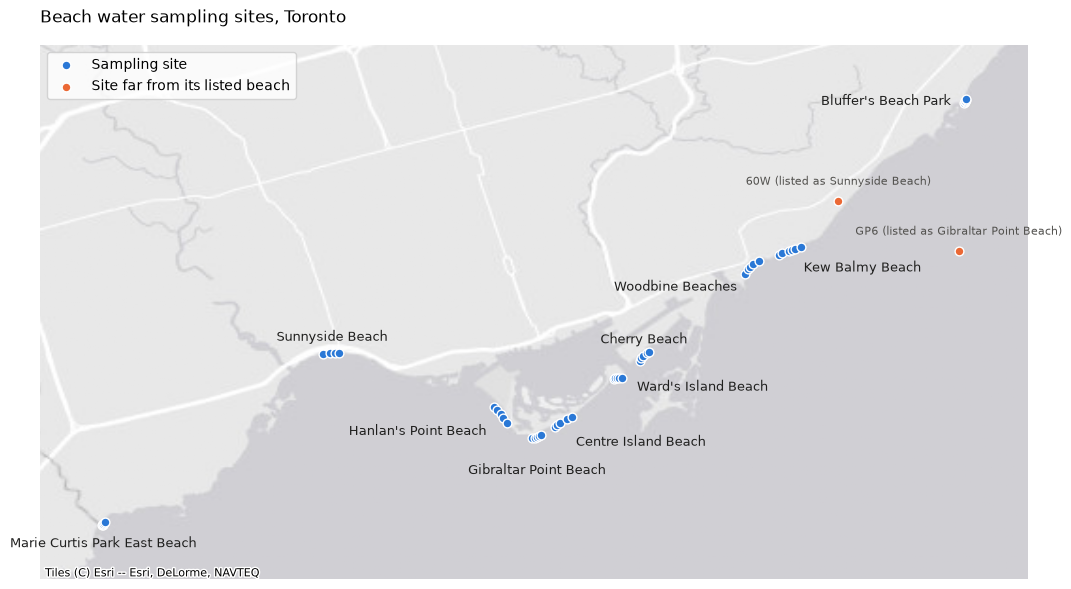

In [26]:
# Web Mercator (EPSG:3857) coordinates in metres, the projection of web map tiles
R = 6_378_137
sites_m = sites.with_columns(
    x=np.radians(pl.col("lon")) * R,
    y=(np.pi / 4 + np.radians(pl.col("lat")) / 2).tan().log() * R,
)

# Sites far from the rest of their beach are drawn separately
outlier_sites = ["GP6", "60W"]
regular = sites_m.filter(~pl.col("siteName").is_in(outlier_sites))
outliers = sites_m.filter(pl.col("siteName").is_in(outlier_sites))

# Label offsets in points (x, y), chosen by hand so names don't overlap
label_offsets = {
    "Marie Curtis Park East Beach": (0, -14),
    "Sunnyside Beach": (0, 12),
    "Hanlan's Point Beach": (-10, -12),
    "Gibraltar Point Beach": (0, -24),
    "Centre Island Beach": (10, -14),
    "Ward's Island Beach": (14, -6),
    "Cherry Beach": (0, 12),
    "Woodbine Beaches": (-10, -14),
    "Kew Balmy Beach": (10, -12),
    "Bluffer's Beach Park": (-10, 0),
}
beach_centres = regular.group_by("beachName").agg(
    pl.col("x").mean(), pl.col("y").mean()
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    regular["x"],
    regular["y"],
    s=40,
    color="#2a78d6",
    edgecolor="white",
    linewidth=1,
    zorder=3,
    label="Sampling site",
)
ax.scatter(
    outliers["x"],
    outliers["y"],
    s=40,
    color="#eb6834",
    edgecolor="white",
    linewidth=1,
    zorder=3,
    label="Site far from its listed beach",
)

for name, x, y in beach_centres.iter_rows():
    dx, dy = label_offsets[name]
    ax.annotate(
        name,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left" if dx > 0 else "right" if dx < 0 else "center",
        va="center",
        fontsize=9,
        color="#1f1f1e",
    )
for beach, site, x, y in outliers.select("beachName", "siteName", "x", "y").iter_rows():
    ax.annotate(
        f"{site} (listed as {beach})",
        (x, y),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#52514e",
    )

pad = 2_500
ax.set_xlim(sites_m["x"].min() - pad, sites_m["x"].max() + pad)
ax.set_ylim(sites_m["y"].min() - pad, sites_m["y"].max() + pad)
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.Esri.WorldGrayCanvas)
ax.set_axis_off()
ax.set_title("Beach water sampling sites, Toronto", loc="left")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

## Samples per beach per day

A warning sign is posted based on the geometric mean of at least five samples from a beach. This section checks how many samples each beach has on each day, and how often there were fewer than five, especially exactly four.

Two counts are used for each beach on each day:
- `n_samples`: rows in the data, meaning samples taken
- `n_results`: rows with an E. coli value, meaning results available for the geometric mean

Count samples and results for every beach on every sampling day.

In [27]:
beach_days = raw.group_by("beachName", "collectionDate").agg(
    n_samples=pl.len(),
    n_results=pl.col("eColi").is_not_null().sum(),
)
beach_days.sort("collectionDate", "beachName").head(10)

beachName,collectionDate,n_samples,n_results
str,date,u32,u32
"""Bluffer's Beach Park""",2007-06-03,5,5
"""Centre Island Beach""",2007-06-03,5,5
"""Kew Balmy Beach""",2007-06-03,6,6
"""Marie Curtis Park East Beach""",2007-06-03,5,5
"""Sunnyside Beach""",2007-06-03,4,4
"""Woodbine Beaches""",2007-06-03,5,5
"""Bluffer's Beach Park""",2007-06-04,5,5
"""Centre Island Beach""",2007-06-04,5,5
"""Cherry Beach""",2007-06-04,5,5


### How often does each combination occur?

Number of beach-days for each combination of samples taken and results available. For example, `n_samples = 5, n_results = 4` means five samples were taken but one has no E. coli value.

In [28]:
beach_days.group_by("n_samples", "n_results").len().sort("n_samples", "n_results")

n_samples,n_results,len
u32,u32,u32
2,2,2
4,0,42
4,2,2
4,3,18
4,4,1883
5,0,597
5,1,10
5,2,7
5,3,10


### Beach-days with fewer than five results, by beach

For each beach, sort the days into groups by number of results: five or more, exactly four, one to three, and none. Days with no results are covered in the next subsection.

In [29]:
(
    beach_days.group_by("beachName")
    .agg(
        beach_days=pl.len(),
        five_or_more=(pl.col("n_results") >= 5).sum(),
        exactly_four=(pl.col("n_results") == 4).sum(),
        one_to_three=pl.col("n_results").is_between(1, 3).sum(),
        none=(pl.col("n_results") == 0).sum(),
    )
    .with_columns(
        share_exactly_four=(pl.col("exactly_four") / pl.col("beach_days")).round(3)
    )
    .sort("beachName")
)

beachName,beach_days,five_or_more,exactly_four,one_to_three,none,share_exactly_four
str,u32,u32,u32,u32,u32,f64
"""Bluffer's Beach Park""",2060,2002,6,4,48,0.003
"""Centre Island Beach""",2027,1925,5,2,95,0.002
"""Cherry Beach""",2059,2013,9,2,35,0.004
"""Gibraltar Point Beach""",2031,1907,5,8,111,0.002
"""Hanlan's Point Beach""",2034,1930,10,3,91,0.005
"""Kew Balmy Beach""",2061,2029,1,2,29,0.0
"""Marie Curtis Park East Beach""",2037,1915,12,1,109,0.006
"""Sunnyside Beach""",2061,110,1883,22,46,0.914
"""Ward's Island Beach""",2032,1949,4,1,78,0.002


### Sunnyside Beach

Sunnyside has four results on almost every day. List its sites in each year to see whether it has only four sampling sites.

In [30]:
(
    raw.filter(pl.col("beachName") == "Sunnyside Beach")
    .group_by(year=pl.col("collectionDate").dt.year())
    .agg(
        n_sites=pl.col("siteName").n_unique(),
        sites=pl.col("siteName").unique().sort().str.join(" "),
    )
    .sort("year")
)

year,n_sites,sites
i32,u32,str
2007,4,"""19W 20W 21W 22W"""
2008,4,"""19W 20W 21W 22W"""
2009,4,"""19W 20W 21W 22W"""
2010,4,"""19W 20W 21W 22W"""
2011,4,"""19W 20W 21W 22W"""
2012,4,"""19W 20W 21W 22W"""
2013,4,"""19W 20W 21W 22W"""
2014,4,"""19W 20W 21W 22W"""
2015,4,"""19W 20W 21W 22W"""


Sunnyside had four sites (19W–22W) from 2007 to 2025. The fifth, `60W`, was added in 2026, but it is about 15 km away (see the map section). So Sunnyside never had five samples from the beach itself, and its four-result days reflect the sampling design, not missed samples.

### Days with exactly four results, by year

Leaving out Sunnyside, count the beach-days with exactly four results in each year, to see whether they cluster in particular years or beaches.

In [31]:
(
    beach_days.filter(
        pl.col("beachName") != "Sunnyside Beach", pl.col("n_results") == 4
    )
    .with_columns(year=pl.col("collectionDate").dt.year())
    .group_by("beachName", "year")
    .len()
    .sort("year")
    .pivot(on="year", index="beachName", values="len")
    .fill_null(0)
    .sort("beachName")
)

beachName,2007,2008,2009,2010,2011,2012,2013,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Bluffer's Beach Park""",0,1,1,0,0,0,0,0,2,0,1,0,0,0,0,1,0,0
"""Centre Island Beach""",0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,1,1
"""Cherry Beach""",1,0,2,0,2,0,0,1,0,0,0,0,0,1,1,1,0,0
"""Gibraltar Point Beach""",0,0,0,0,2,1,0,0,1,0,1,0,0,0,0,0,0,0
"""Hanlan's Point Beach""",1,1,0,1,0,0,0,0,1,1,0,1,1,0,0,1,0,2
"""Kew Balmy Beach""",0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Marie Curtis Park East Beach""",1,0,0,1,0,0,1,0,1,0,0,1,2,0,0,2,0,3
"""Ward's Island Beach""",0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,1
"""Woodbine Beaches""",0,0,0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,0


### Days with no results

The City's *About Beach Water Quality* page says: "Occasionally TPH is not able to test the water quality due to circumstances such as adverse weather conditions." The data still has a row for every site on those days, with `eColi` blank.

Weather would likely affect many beaches on the same day. For each date with at least one beach without results, count how many beaches had none. Ten means every beach.

In [32]:
no_result_days = (
    beach_days.group_by("collectionDate")
    .agg(beaches_no_results=(pl.col("n_results") == 0).sum())
    .filter(pl.col("beaches_no_results") > 0)
)

no_result_days.group_by("beaches_no_results").len().sort("beaches_no_results")

beaches_no_results,len
u32,u32
1,73
2,22
3,10
4,11
5,10
6,21
7,7
8,1
9,2


Dates when no beach had results. The most recent ones may be results not yet published rather than missed sampling.

In [33]:
no_result_days.filter(pl.col("beaches_no_results") == 10).sort("collectionDate")

collectionDate,beaches_no_results
date,u32
2010-05-24,10
2011-05-24,10
2011-05-26,10
2013-05-04,10
2017-03-02,10
2017-04-27,10
2017-05-04,10
2017-05-19,10
2017-05-22,10


Most of these dates are before the season properly starts (March to mid-May), for example 2 March 2017. They are the early one-off dates found in the sampling-frequency section, and they have rows but no results. Only a few fall mid-season (2020-07-16, 2026-07-17 and 2026-07-18), which fits weather or a citywide problem. The last two dates (2026-09-08 and 2026-09-16) may be results not yet published.